## [Experiment #2] Sample notebook to simualate augmentation and dataloaders / dataset preparations

#### [Exp 1]: Augmentation simulation

In [1]:
%reload_ext autoreload
%autoreload 2

import sys, os
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.preprocessing import (
    preprocess_image_retina,
    preprocess_mask,
    derive_fov_mask_path_from_image,
)
from src.data.augmentations import get_train_augs

# ---- Config ----
TARGET = 512
SEED = 1337  # set to None for different results each run

def _overlay(img_hw: np.ndarray, msk_hw: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    img_rgb = np.stack([img_hw, img_hw, img_hw], axis=-1)
    red = np.zeros_like(img_rgb); red[..., 0] = 1.0
    overlay = (1 - alpha) * img_rgb + alpha * (red * msk_hw[..., None])
    return np.clip(overlay, 0.0, 1.0)

def visualize_augmentations(
    image_path: str,
    label_path: str,
    n_samples: int = 6,
    apply_fov_after: bool = True,
    gamma: float = 0.9,
    clahe_clip: float = 2.0,
    clahe_tiles: int = 8,
):
    # ---- deterministic randomness (optional) ----
    if SEED is not None:
        import random
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)

    # ---- preprocess WITHOUT applying FOV inside (we'll gate after) ----
    img = preprocess_image_retina(
        image_path, target_size=TARGET, use_gamma=True, gamma=gamma,
        clahe_clip=clahe_clip, clahe_tiles=clahe_tiles,
        apply_fov=False, mask_path=None, auto_discover_mask=False,
    )[0]  # (H,W)

    msk = preprocess_mask(label_path, target_size=TARGET)[0]  # (H,W) {0,1}

    if apply_fov_after:
        fov_path = derive_fov_mask_path_from_image(image_path)
        fov = preprocess_mask(fov_path, target_size=TARGET)[0]
        img = (img * fov).astype(np.float32)

    augs = get_train_augs(size=TARGET)

    cols = n_samples + 1
    fig, axes = plt.subplots(3, cols, figsize=(3.4*cols, 9))
    if cols == 1: axes = np.asarray(axes).reshape(3,1)

    axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=1);  axes[0, 0].set_title("Baseline Image", fontsize=10)
    axes[1, 0].imshow(msk, cmap="gray", vmin=0, vmax=1);  axes[1, 0].set_title("Baseline Mask", fontsize=10)
    axes[2, 0].imshow(_overlay(img, msk));                 axes[2, 0].set_title("Baseline Overlay", fontsize=10)
    for r in range(3): axes[r, 0].axis("off")

    for j in range(1, cols):
        out = augs(image=img, mask=msk)
        img_t, msk_t = out["image"], out["mask"]
        if msk_t.ndim == 3: msk_t = msk_t[0]
        img_aug = img_t[0].cpu().numpy()
        msk_aug = (msk_t.cpu().numpy() > 0.5).astype(np.float32)

        axes[0, j].imshow(img_aug, cmap="gray", vmin=0, vmax=1); axes[0, j].set_title(f"Aug #{j} — Image", fontsize=10)
        axes[1, j].imshow(msk_aug, cmap="gray", vmin=0, vmax=1); axes[1, j].set_title(f"Aug #{j} — Mask", fontsize=10)
        axes[2, j].imshow(_overlay(img_aug, msk_aug));           axes[2, j].set_title(f"Aug #{j} — Overlay", fontsize=10)
        for r in range(3): axes[r, j].axis("off")

    plt.tight_layout(); plt.show()


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\..\src\data\augmentations.py:33: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(


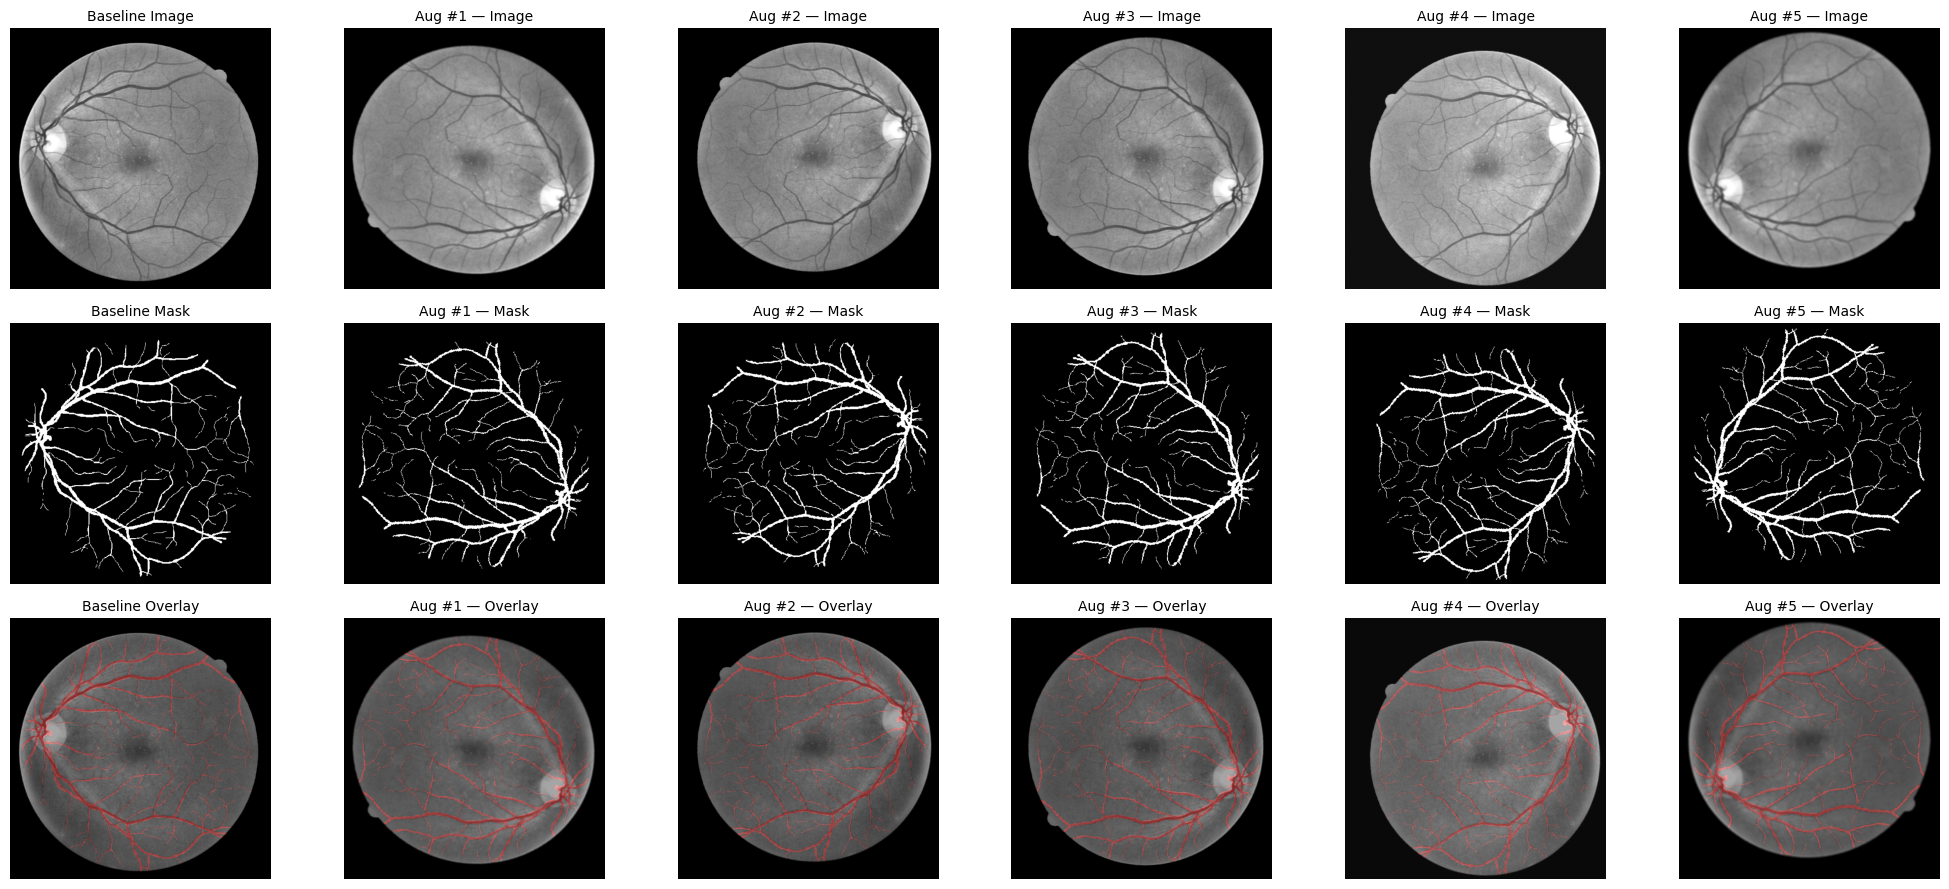

In [2]:
# Pick one image + its manual GT
img_path = "../data/raw/DRIVE/training/images/21_training.png"
lab_path = "../data/raw/DRIVE/training/1st_manual/21_manual1.png"

visualize_augmentations(
    image_path=img_path,
    label_path=lab_path,
    n_samples=5,          # how many randomized augs to show
    apply_fov_after=True, # multiply FOV after preprocessing (your strict preproc is happy)
    gamma=0.9,
    clahe_clip=2.0,
    clahe_tiles=8,
)


In [3]:
from src.data.prepare_dataset import (
    build_all_train_pairs, build_pairs_for_split,
    sanity_check_counts, sanity_check_sample_alignment, assert_dataset_layout
)
from src.data.augmentations import get_train_augs, get_val_augs
from src.data.dataloader import make_loaders

# 1) Sanity check one dataset
print(sanity_check_counts("../data/raw/DRIVE", split="training"))
assert_dataset_layout("../data/raw/DRIVE", split="training")

# 2) Build pairs
train_pairs_all = build_all_train_pairs(raw_root="../data/raw", datasets=("DRIVE","CHASEDB1","STARE"))

print("Sample alignment:", sanity_check_sample_alignment(train_pairs_all, k=5))

# 3) Make loaders (80/20 split)
train_loader, val_loader = make_loaders(
    train_pairs=train_pairs_all,
    image_size=512,
    batch_size=6,
    num_workers=0,                    # set >0 outside notebooks
    seed=1337,
    strict_fov=True,
    augs_train=get_train_augs(512),
    augs_val=get_val_augs(512),
)

# 4) Peek a batch
batch = next(iter(train_loader))
print(batch["image"].shape, batch["mask"].shape)  # e.g., torch.Size([6, 1, 512, 512])


{'images': 20, 'labels': 20, 'fov_masks': 20}
Sample alignment: [('21_training.png', '21_manual1.png'), ('22_training.png', '22_manual1.png'), ('23_training.png', '23_manual1.png'), ('24_training.png', '24_manual1.png'), ('25_training.png', '25_manual1.png')]


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([6, 1, 512, 512]) torch.Size([6, 1, 512, 512])


In [4]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.prepare_dataset import (
    build_all_train_pairs, build_pairs_for_split,
    sanity_check_counts, sanity_check_sample_alignment, assert_dataset_layout
)
from src.data.augmentations import get_train_augs, get_val_augs
from src.data.dataloader import make_loaders
from src.data.preprocessing import preprocess_mask, derive_fov_mask_path_from_image


In [5]:
%reload_ext autoreload
%autoreload 2
# Quick file-level sanity
print("DRIVE training counts:", sanity_check_counts("../data/raw/DRIVE", split="training"))
assert_dataset_layout("../data/raw/DRIVE", split="training")

# Build path pairs across datasets (training split)
train_pairs_all = build_all_train_pairs(
    raw_root="../data/raw",
    datasets=("DRIVE","CHASEDB1","STARE"),
    label_folder="1st_manual",
)
print("Pairs total:", len(train_pairs_all))
print("First 5 pairs (image, label):", sanity_check_sample_alignment(train_pairs_all, k=5))


DRIVE training counts: {'images': 20, 'labels': 20, 'fov_masks': 20}
Pairs total: 44
First 5 pairs (image, label): [('21_training.png', '21_manual1.png'), ('22_training.png', '22_manual1.png'), ('23_training.png', '23_manual1.png'), ('24_training.png', '24_manual1.png'), ('25_training.png', '25_manual1.png')]


In [6]:
%reload_ext autoreload
%autoreload 2
train_loader, val_loader = make_loaders(
    train_pairs=train_pairs_all,
    val_pairs=None,          # 80/20 split inside
    image_size=512,
    batch_size=6,
    num_workers=0,           # keep 0 in notebooks (Windows)
    seed=1337,
    strict_fov=True,
    augs_train=get_train_augs(512),
    augs_val=get_val_augs(512),
)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 6 | Val batches: 2


In [7]:
batch = next(iter(train_loader))
print("batch keys:", list(batch.keys()))
# Expect: ['image','mask','fov','image_path','label_path']

print("shapes:",
      batch["image"].shape,
      batch["mask"].shape,
      batch["fov"].shape)


batch keys: ['image', 'mask', 'fov', 'image_path', 'label_path']
shapes: torch.Size([6, 1, 512, 512]) torch.Size([6, 1, 512, 512]) torch.Size([6, 1, 512, 512])


In [8]:
%reload_ext autoreload
%autoreload 2

# re-import after code changes
from src.data.augmentations import get_train_augs, get_val_augs
from src.data.dataloader import make_loaders


def overlay_red(img_hw: np.ndarray, msk_hw: np.ndarray, alpha: float = 0.35):
    """img_hw, msk_hw in [0,1]; return RGB overlay for display."""
    img_rgb = np.stack([img_hw, img_hw, img_hw], axis=-1)
    red = np.zeros_like(img_rgb); red[..., 0] = 1.0
    return np.clip((1 - alpha) * img_rgb + alpha * (red * msk_hw[..., None]), 0.0, 1.0)

def show_batch_grid(batch, max_rows=4, title="Batch"):
    """Show up to max_rows samples: image | mask | overlay."""
    imgs = batch["image"].cpu().numpy()   # [B,1,H,W]
    msks = batch["mask"].cpu().numpy()    # [B,1,H,W]
    B = min(max_rows, imgs.shape[0])
    fig, axes = plt.subplots(B, 3, figsize=(10, 3*B))
    if B == 1: axes = np.array([axes])
    for i in range(B):
        x = imgs[i,0]
        y = msks[i,0]
        ov = overlay_red(x, y)
        axes[i,0].imshow(x, cmap="gray", vmin=0, vmax=1); axes[i,0].set_title("Image"); axes[i,0].axis("off")
        axes[i,1].imshow(y, cmap="gray", vmin=0, vmax=1); axes[i,1].set_title("Mask");  axes[i,1].axis("off")
        axes[i,2].imshow(ov, vmin=0, vmax=1);             axes[i,2].set_title("Overlay"); axes[i,2].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def fov_after_consistency_check(batch, idx=0):
    img = batch["image"][idx,0].cpu().numpy()
    fov = batch["fov"][idx,0].cpu().numpy()   # <— use transformed FOV directly

    outside = (1.0 - fov) * img
    total_outside = float(outside.sum())
    num_nonzero_outside = int((outside > 1e-6).sum())

    print("Sample:", Path(batch["image_path"][idx]).name)
    print("Sum outside FOV:", total_outside, "| pixels > 1e-6 outside:", num_nonzero_outside)

    fig, axs = plt.subplots(1, 3, figsize=(11,3))
    axs[0].imshow(img, cmap="gray", vmin=0, vmax=1); axs[0].set_title("Image (post-augs+FOV)"); axs[0].axis("off")
    axs[1].imshow(fov, cmap="gray", vmin=0, vmax=1); axs[1].set_title("FOV (post-augs)"); axs[1].axis("off")
    axs[2].imshow(outside, cmap="gray");             axs[2].set_title("Image × (1−FOV)");  axs[2].axis("off")
    plt.tight_layout(); plt.show()


Train batch shapes: torch.Size([6, 1, 512, 512]) torch.Size([6, 1, 512, 512])


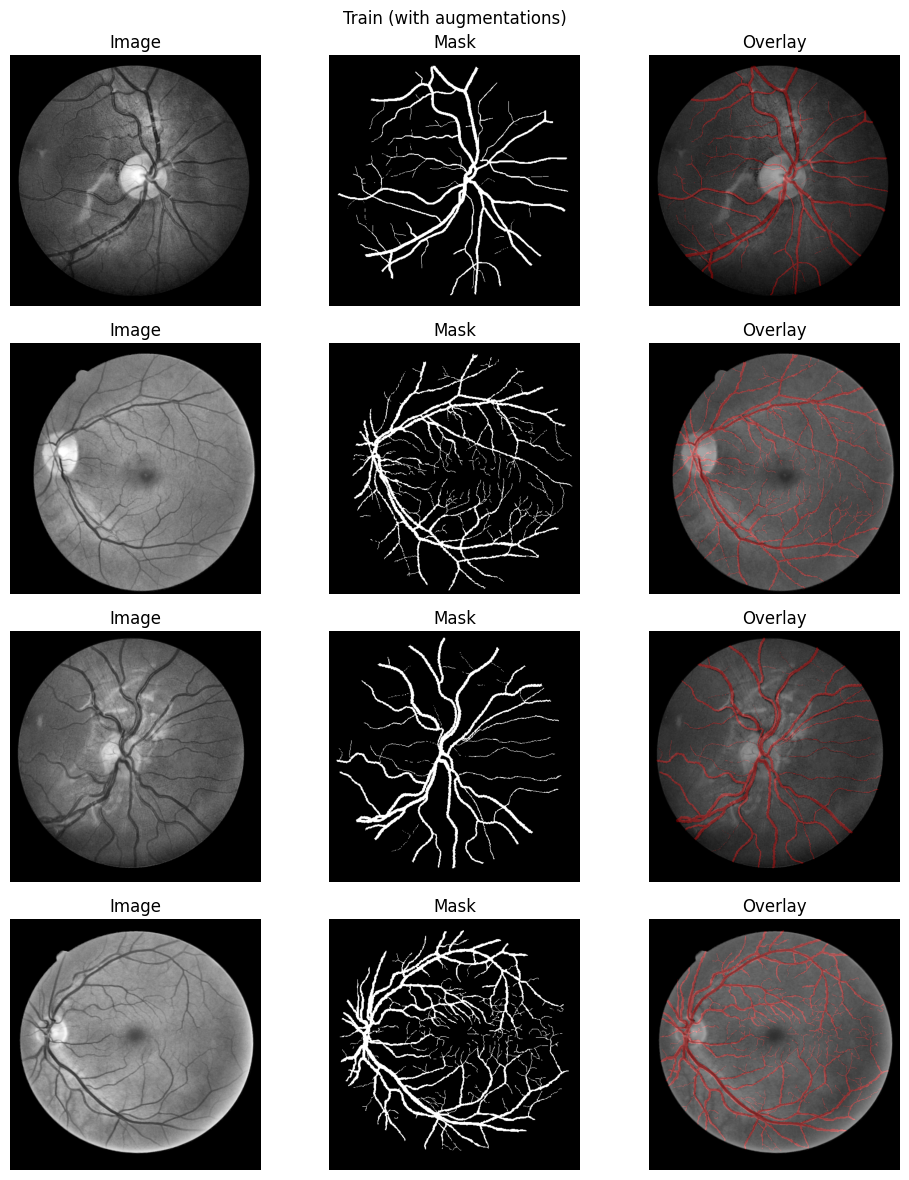

Sample: 16_training.jpg
Sum outside FOV: 0.0 | pixels > 1e-6 outside: 0


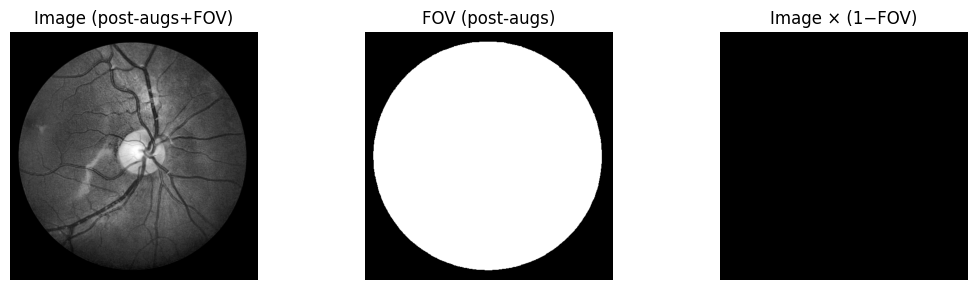

In [9]:
train_batch = next(iter(train_loader))
print("Train batch shapes:", train_batch["image"].shape, train_batch["mask"].shape)
show_batch_grid(train_batch, max_rows=4, title="Train (with augmentations)")
fov_after_consistency_check(train_batch, idx=0)


Val batch shapes: torch.Size([6, 1, 512, 512]) torch.Size([6, 1, 512, 512])


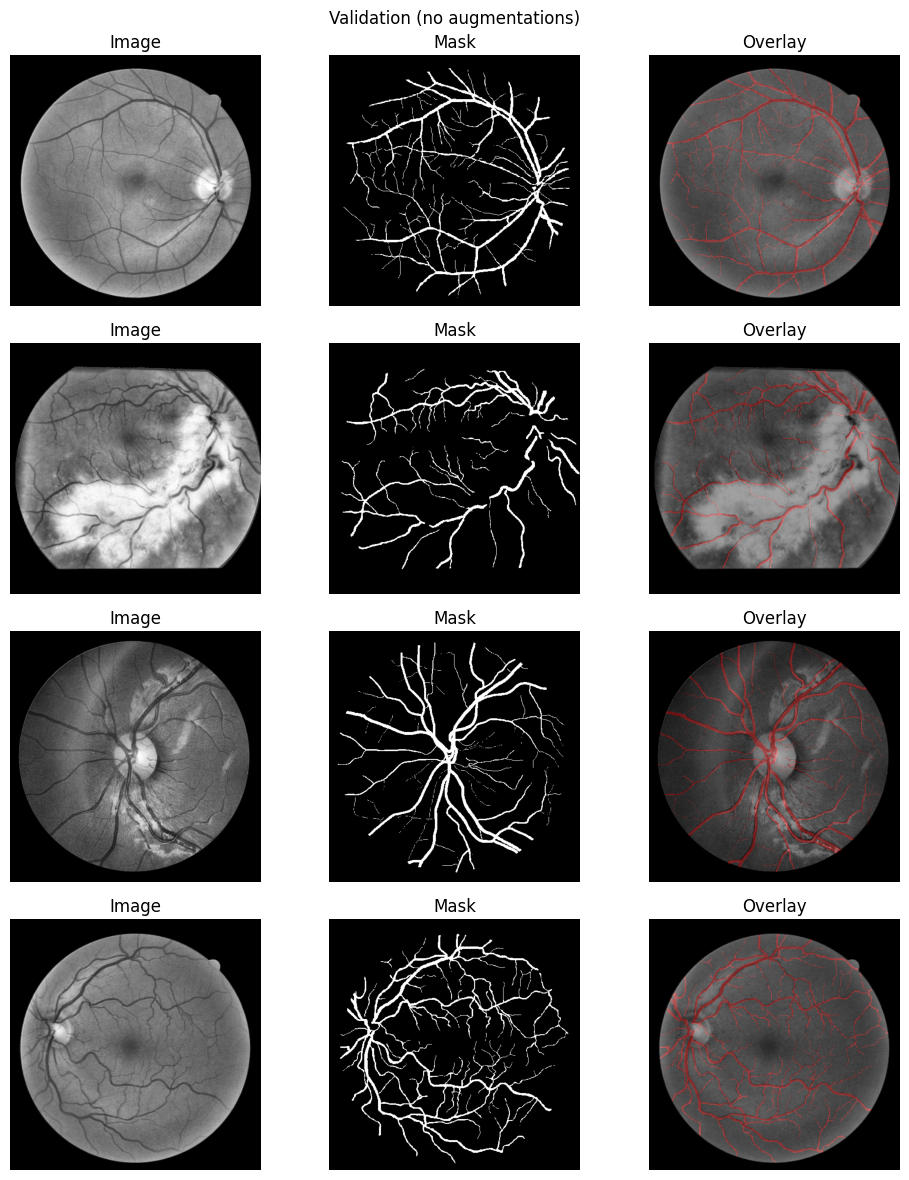

Sample: 33_training.png
Sum outside FOV: 0.0 | pixels > 1e-6 outside: 0


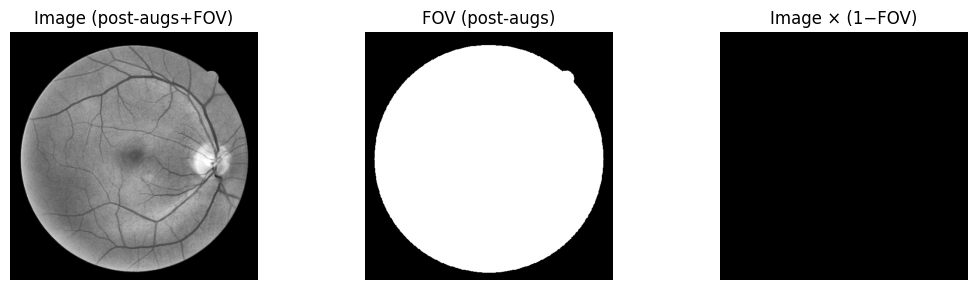

In [10]:
val_batch = next(iter(val_loader))
print("Val batch shapes:", val_batch["image"].shape, val_batch["mask"].shape)
show_batch_grid(val_batch, max_rows=4, title="Validation (no augmentations)")
fov_after_consistency_check(val_batch, idx=0)


In [11]:
def quick_asserts(batch):
    x, y = batch["image"], batch["mask"]
    assert x.ndim == 4 and y.ndim == 4, "Expected 4D tensors [B,1,H,W]"
    assert x.shape[1] == 1 and y.shape[1] == 1, "Expected single-channel data"
    assert (y.unique().cpu().numpy() <= 1).all(), "Mask should be binary-ish (0/1)"
    assert x.min() >= 0.0 and x.max() <= 1.0, "Image should be in [0,1]"
    print("Invariants OK.")

quick_asserts(train_batch)
quick_asserts(val_batch)


Invariants OK.
Invariants OK.
